# Experiment 3.5 : EGFR-MAPK Cascade Activity

**Drug Modeled:** Gefitinib

**Condition Tested:** Gefitinib influence on the MAPK cascade

**Research Question:** How does EGFR inhibition propagate through the MAPK signaling cascade to alter proliferation?

![Dose-response](figures/network_diagram.png)

## Figure 3.5A

**Figure 3.5A.** Representation of EGFR-MAPK cascade. The star (*) next to specific kinases and GTP-ases (in the case of RAS) indicates the active state, and gefitinib blocks phosphates on the EGFR tyrosine residues from binding to Grb2, a necessary component for RAS to get activated (currently lumped into EGFR --> RAS). ERK activation influences activation of transcription factors for the CCND1 gene, coding for Cyclin D, the regulatory protein for cellular proliferation. Once Cyclin D concentration increases, proliferation rates increase as cells.

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# y : [EGFR, RAS, RAF, MEK, ERK, CycD, P]
def pathway(t, y, params):
    # External factors
    EGF = params["EGF"]
    G = params["G"]
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]
    k_G = params["k_G"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]


## Design Notes : Pathway ODE Implementation

The signaling pathway is implemented as a system of seven coupled ordinary differential equations (ODEs), with the state vector defined as $$y(t) = [\mathrm{EGFR}^{*}, \mathrm{RAS}^{*}, \mathrm{RAF}^{*}, \mathrm{MEK}^{*}, \mathrm{ERK}^{*}, \mathrm{CycD}, \mathrm{P}]$$

Only the **active forms** of the signaling proteins are explicitly represented as state variables. Their inactive concentrations are instead calculated from fixed total concentrations, e.g. $$[\mathrm{EGFR}] = [\mathrm{EGFR}]_{tot} - [\mathrm{EGFR}^{*}]$$

This reduces the number of dynamic variables while enforcing conservation of each protein. total protein cocentrations are currently normalized at 1.0, allowing the model to focus on pathway dynamics without requiring experimentally calibrated absolute concentrations. 

The model distinguishes between **external inputs, parameters, state variables, and derived quantities.** Epidermal growth factor ($EGF$) concentration, gefitinib ($G$) concentration, $IC_{50}$, and the Hill coefficient ($n$) are supplied through the $params$ dictionary, while the state vector contains quantities that evolve over time. The gefitinib effect is represented using the Hill-type inhibition factor seen in Experiment 3, $$H(G) = \frac{1}{1 + (\frac{G}{IC_{50}})^n}$$

which scales EGF-dependent EGFR activation. This was chosen to represent the nonlinear concentration-dependent inhibition of EGFR by gefitinib without explicitly modeling drug-receptor binding kinetics.

Each downstream signaling component is represented using a simplified **activation-deactivation balance:** $$\frac{dX^*}{dt} = \text{activation} - \text{deactivation}$$

Activation depends on the active upstream component and the available inactive pool of the downstream component, while deactivation is modeled as a first-order process. This provides a mechanistic representation of signal propagation through the EGFR-RAS-RAF-MEK-ERK cascade while keeping the system sufficiently small for initial analysis.

RAS is treated as an active molecular switch rather than a kinase; therefore, RAS_star represents the active state of RAS rather than specfically a phosphorylated form. Similarly, the $*$ notation is used generally to denote an **active signaling state.**

The final two equations extend the signaling cascade to cellular behavior. ERK activity drives Cyclin D production, while Cyclin D drives proliferation. Cyclin D and proliferation each have first-order loss terms, allowing the model to reach a steady state rather than increase indefinitely.

Finally the derivative function recieves $\mathrm{t}$ even though the current equations do not explicitly depend on time. This is required by **solve_ivp** and also preserves the model structure for future extensions to which EGF or gefitinib concentration may vary with time or, eventually, with both space and time. This is particularly important for the planned coupling to the tissue-level diffusion model, where the constant $G$ can eventually be replaced by a local drug concentration $G(x, t)$.

The signaling ODE system was simulated over increasing time intervals until both the maximum relative rate of change and the maximum relative change in the final state fell below $10^{-6}$. At $T$=$80$, the maximum relative rate was $5.90 * 10^{-10}$, while the maximum relative state change between $T$=$40$ and $T$=$80$ was $3.77 * 10^{-7}$. Thus, $T$=$80$ was sufficient to establish steady-state convergence.

**Current limitation:** The rate constants and total concentrations are normalized/placeholder values rather than experimentally calibrated parameters. Therefore, the current model should be interpreted primarily as a mechanistic framework for examining pathway dynamics and relative responses. Parameter calibration and validation against experimental data are subsequent steps rather than assumptions of the current implementation.

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters

# Initial state vector
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Time range
t_span = (0, 80)

# Time evaluation array
t_eval = np.linspace(0, 80, 500)

# External parameter value dictionary
params = {
    "EGF" : 1.0,
    "G" : 0.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_G" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

In [4]:
# Solving pathway dynamics

solution = solve_ivp(pathway, t_span, y0, t_eval=t_eval, args=(params,))

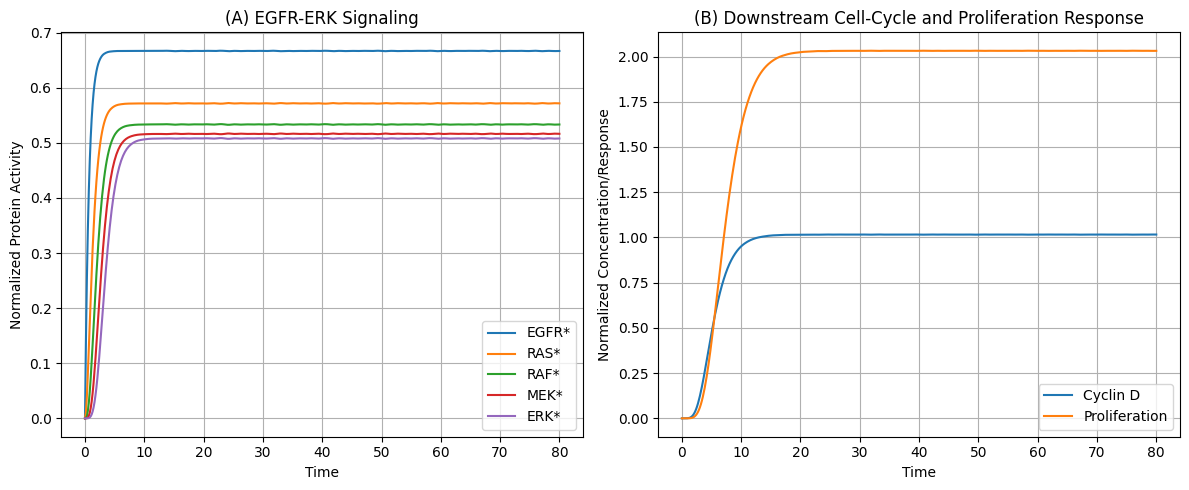

In [5]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: signaling pathway
ax1.plot(solution.t, solution.y[0], label="EGFR*")
ax1.plot(solution.t, solution.y[1], label="RAS*")
ax1.plot(solution.t, solution.y[2], label="RAF*")
ax1.plot(solution.t, solution.y[3], label="MEK*")
ax1.plot(solution.t, solution.y[4], label="ERK*")

ax1.set_xlabel("Time")
ax1.set_ylabel("Normalized Protein Activity")
ax1.set_title("(A) EGFR-ERK Signaling")

ax1.legend()
ax1.grid()

# Right: downstream response
ax2.plot(solution.t, solution.y[5], label="Cyclin D")
ax2.plot(solution.t, solution.y[6], label="Proliferation")

ax2.set_xlabel("Time")
ax2.set_ylabel("Normalized Concentration/Response")
ax2.set_title("(B) Downstream Cell-Cycle and Proliferation Response")

ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

## Figure 3.5B

**Figure 3.5B.** Temporal dynamics of the mechanistic EGFR signaling model.
(A) Activation dynamics across the EGFR–RAS–RAF–MEK–ERK cascade. (B) Propagation of ERK signaling into Cyclin D accumulation and the modeled proliferation-associated response.

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters

# Gefitinib concentration array
G_values = np.logspace(-2, 1, 500)

In [7]:
# Solving steady states

steady_states = []

for G in G_values:
    params["G"] = G
    solution = solve_ivp(pathway, t_span, y0, t_eval=t_eval, args=(params,))

    steady_states.append(solution.y[:, -1])

steady_states = np.array(steady_states)

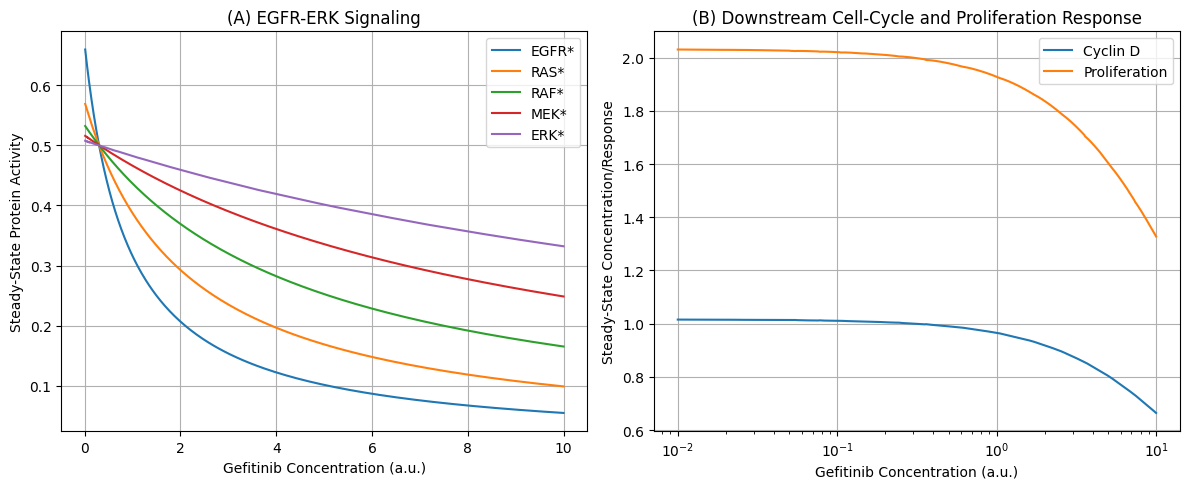

In [8]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: signaling pathway
ax1.plot(G_values, steady_states[:, 0], label="EGFR*")
ax1.plot(G_values, steady_states[:, 1], label="RAS*")
ax1.plot(G_values, steady_states[:, 2], label="RAF*")
ax1.plot(G_values, steady_states[:, 3], label="MEK*")
ax1.plot(G_values, steady_states[:, 4], label="ERK*")

ax1.set_xlabel("Gefitinib Concentration (a.u.)")
ax1.set_ylabel("Steady-State Protein Activity")
ax1.set_title("(A) EGFR-ERK Signaling")

ax1.legend()
ax1.grid()

# Right: downstream response
ax2.plot(G_values, steady_states[:, 5], label="Cyclin D")
ax2.plot(G_values, steady_states[:, 6], label="Proliferation")

ax2.set_xlabel("Gefitinib Concentration (a.u.)")
ax2.set_ylabel("Steady-State Concentration/Response")
ax2.set_title("(B) Downstream Cell-Cycle and Proliferation Response")

ax2.legend()
ax2.grid()

plt.xscale("log")
plt.tight_layout()
plt.show()

## Figure 3.5C

**Figure 3.5C.** Steady-state response of the EGFR–ERK signaling pathway and downstream cellular processes to gefitinib concentration. The ODE system was solved to steady state across a range of gefitinib concentrations while other model parameters were held constant. (A) Increasing gefitinib concentration progressively decreases the steady-state activity of EGFR*, RAS*, RAF*, MEK*, and ERK*, demonstrating propagation of EGFR inhibition through the modeled signaling cascade. (B) Reduced ERK* activity decreases Cyclin D accumulation and, consequently, the modeled proliferation response. Gefitinib concentration is shown on a logarithmic scale to resolve the nonlinear transition across the concentration range.

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters

# ERK steady state values
ERK_ss = []

# Proliferation steady state values
P_ss = []

# ERK normalized array
ERK_norm = []

# Proliferation normalized array
P_norm = []

In [10]:
# Solving ERK and Proliferation steady states

for G in G_values:
    params["G"] = G
    
    solution = solve_ivp(pathway, t_span, y0, 
                            t_eval=t_eval, args=(params,))
    
    ERK_ss.append(solution.y[4, -1])
    P_ss.append(solution.y[6, -1])

ERK_norm = np.array(ERK_ss) / ERK_ss[0]

P_norm = np.array(P_ss) / P_ss[0]


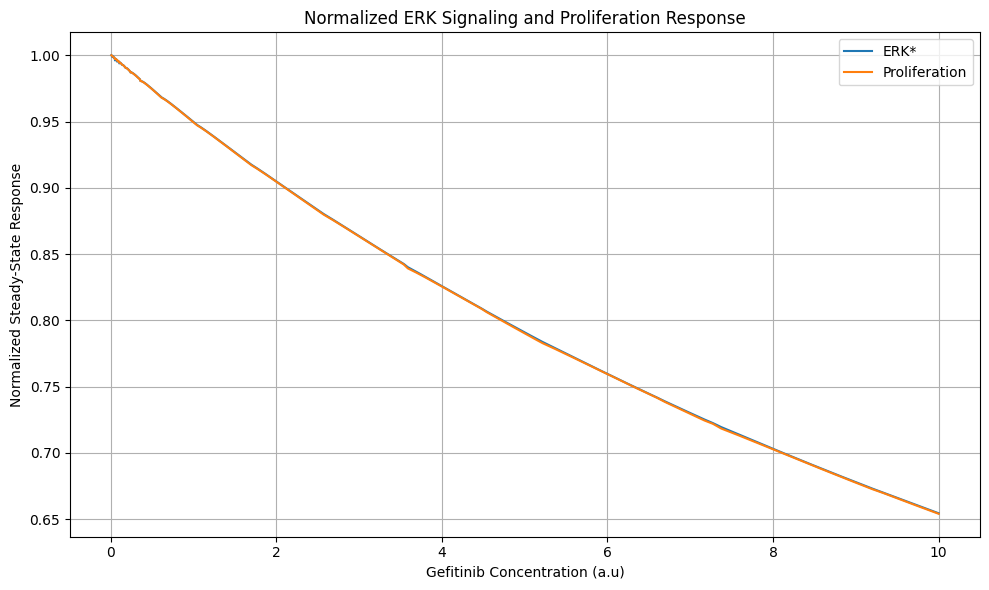

In [11]:
# Plot
plt.figure(figsize=(10, 6))

plt.plot(G_values, ERK_norm, label="ERK*")
plt.plot(G_values, P_norm, label="Proliferation")

plt.title("Normalized ERK Signaling and Proliferation Response")
plt.xlabel("Gefitinib Concentration (a.u)")
plt.ylabel("Normalized Steady-State Response")

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Figure 3.5D

**Figure 3.5D.** 

## More Testing

This section serves as extensive testing to ensure my first ODE draft functions correctly before improving complexity or introducing proper biological constant values or concentrations.

In [12]:
# Test 1 : Steady State Purity, checking that steady states converge and 
# the derivatives at the final state vector are close to or are 0.

# Safety check
params["G"] = 0.0

solution = solve_ivp(pathway, t_span, y0, t_eval=t_eval, args=(params,))

final_state = solution.y[:, -1]
final_derivatives = pathway(solution.t[-1], final_state, params)

print(final_derivatives)

[np.float64(0.00014634604245500338), np.float64(-0.00018965379139207483), np.float64(0.00020532148444019072), np.float64(-0.00021312159661512897), np.float64(0.00021689003203728685), np.float64(-0.0002139551663766781), np.float64(0.00021510197155394373)]


In [13]:
# Test 2 : Expansion of time span, checking that 40 or 30 are not comfortable values
# for the system, and the steady state is always reached, regardless of time span.

species = ["EGFR*", "RAS*", "RAF*", "MEK*", "ERK*", "CycD", "P"]

T_values = [40, 80, 160, 320, 640]

previous_final_state = None

for T in T_values:

    t_eval = np.linspace(0, T, 2000)

    solution = solve_ivp(
        pathway,
        [0, T],
        y0,
        args=(params,),
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-12
    )

    final_state = solution.y[:, -1]

    # Derivative convergence
    final_derivatives = pathway(
        solution.t[-1],
        final_state,
        params
    )

    relative_rates = (
        np.abs(final_derivatives)
        / np.maximum(np.abs(final_state), 1e-12)
    )

    max_relative_rate = np.max(relative_rates)

    print(f"\nT = {T}")
    print(f"max |dy/dt| = {np.max(np.abs(final_derivatives)):.3e}")
    print(f"max relative rate = {max_relative_rate:.3e}")

    # State-change convergence
    if previous_final_state is not None:

        relative_state_change = (
            np.abs(final_state - previous_final_state)
            / np.maximum(np.abs(final_state), 1e-12)
        )

        max_state_change = np.max(relative_state_change)

        print(f"max relative state change = {max_state_change:.3e}")

        for name, change in zip(species, relative_state_change):
            print(f"{name:10s}: {change:.3e}")

    previous_final_state = final_state


T = 40
max |dy/dt| = 3.615e-07
max relative rate = 1.779e-07

T = 80
max |dy/dt| = 2.998e-10
max relative rate = 5.902e-10
max relative state change = 3.770e-07
EGFR*     : 2.031e-10
RAS*      : 3.046e-10
RAF*      : 3.554e-10
MEK*      : 3.808e-10
ERK*      : 3.935e-10
CycD      : 2.085e-08
P         : 3.770e-07

T = 160
max |dy/dt| = 9.224e-11
max relative rate = 1.816e-10
max relative state change = 2.724e-10
EGFR*     : 1.406e-10
RAS*      : 2.109e-10
RAF*      : 2.461e-10
MEK*      : 2.636e-10
ERK*      : 2.724e-10
CycD      : 1.362e-10
P         : 6.808e-11

T = 320
max |dy/dt| = 5.006e-10
max relative rate = 9.855e-10
max relative state change = 5.360e-10
EGFR*     : 2.766e-10
RAS*      : 4.149e-10
RAF*      : 4.841e-10
MEK*      : 5.187e-10
ERK*      : 5.360e-10
CycD      : 2.680e-10
P         : 1.340e-10

T = 640
max |dy/dt| = 4.455e-10
max relative rate = 8.771e-10
max relative state change = 7.229e-11
EGFR*     : 3.731e-11
RAS*      : 5.597e-11
RAF*      : 6.529e-11
MEK*   